# Model white-noise Spikey light curve

This notebook uses a simple white nosie light curve of a synthetic Spikey model given by the model parameters of Hu+2020. This analysis is used to benchmark the performance of different Bayesian inference softwares and reveal potential biases in the model itself. Throughout this notebook we use wide uninformative uniform priors.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import os
import sys
import json
import copy
import datetime
import warnings

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
import jax
from jax import random
from jax import numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import utils as ut
import plots as pt
import bayes as bs
pt.setup()

INFO:2026-04-15 00:43:27,512:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [3]:
# Hide warnings
warnings.filterwarnings("ignore")

In [4]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
fdir = path / 'figures'
c0 = 'lightseagreen'
c1 = 'mediumorchid'

---
## 0. Setup
---

Before doing any modelling we define a few things needed for the analysis.

In [5]:
def generate_noise_model(cadence=1, tdur=3, noise_level=1e-3, DRW=False, plot_model=False, plot_lc=False):
    """Function to generate a fiducial model template for Spikey with added Gaussian noise.
    Fiducial model: 1-d cadence, 3-yr duration, and 1-ppt noise level.
    """
    # First we create a time array for the model (1-d cadence, 3-yr duration)
    tdur = tdur * ut.year2day()
    dt   = cadence
    time = smbhb.time(tdur, dt)
    # Initialise model parameters and disable AGN red noise
    params = smbhb.model_params()
    # Disabling DRW model component
    if not DRW:
        params.sigma = 0
    # Initialise model with model parameters
    # NOTE: The default parameters of class is the Spikey model parameters from Hu+2020
    model = smbhb.model(params)
    # Generate model light curve
    dm = model.light_curve(time, df=True)
    # Show model light curve
    if plot_model:
        pt.plot_model(dm);
    # Create data frame with model time series
    df = pd.DataFrame()
    df['time'] = dm.time
    df['flux'] = dm.flux
    # Add a Kepler-like Gaussian noise level to the model
    np.random.seed(params.seed)  # Reproducibility
    df.flux += np.random.normal(0, noise_level, len(time))
    df['flux_err'] = np.full(df.shape[0], 2*noise_level)
    # Plot "noisy" light curve
    if plot_lc:
        pt.plot_lc(df);
    # Finito!
    return df, params

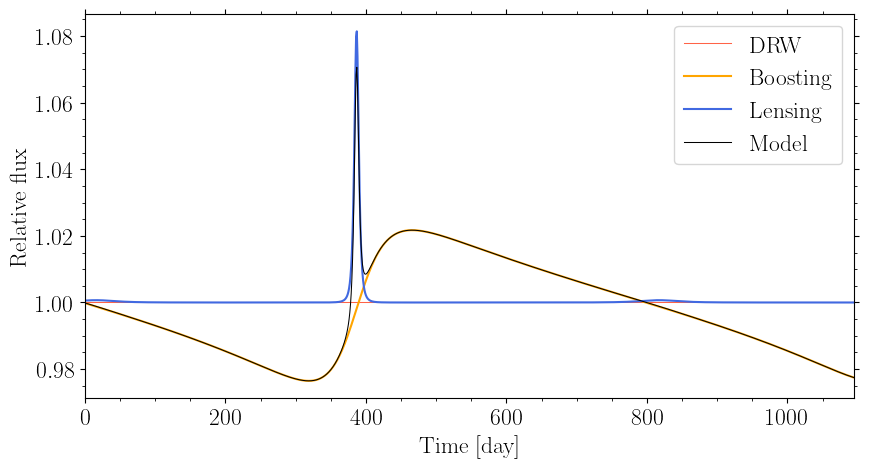

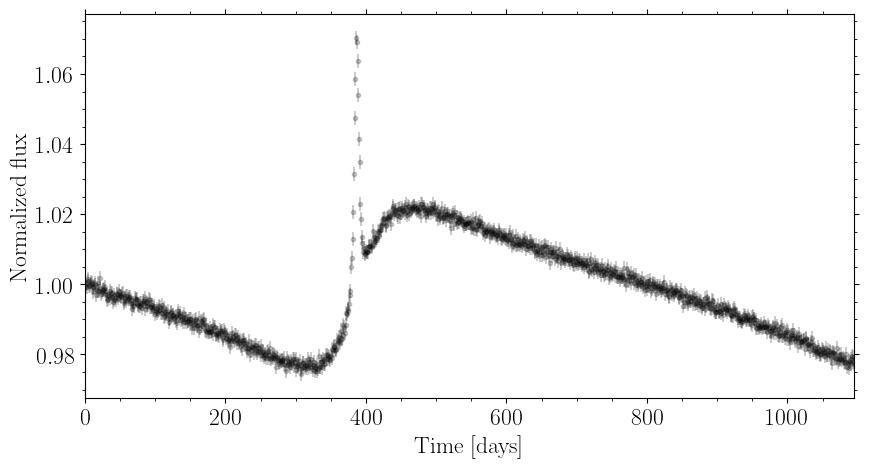

In [6]:
# Generate fiducial model template
df, params = generate_noise_model(cadence=1, tdur=3, noise_level=1e-3, plot_model=True, plot_lc=True)

In [11]:
# Load default JAXNS priors for Spikey 
priors       = bs.model_priors(params, model='DM')
priors_logMq = bs.model_priors(params, model='DM', logMq=True)

---
## 1. Test Bayesian softwares
---

In this section we test the accuracy and reliability of MCMC with `NumPyro` and nested sampling with both `UltraNest` and `JAXNS`:

- MCMC with `NumPyro` performs the worst in both model prediction, accuracy, and model reliability. A fully multimodal posterior landscape is retrieved suggesting that nested sampling is much more reliable for the specific (toy) model.
  
- Nested sampling with `UltraNest` perform relatively well in terms of posterior precision, the model prediction and accuracy is rather bad. While the software allows to take advantage of a `ReactiveNestedSampler` plus wrap the prior range (fully avoiding the bimodality in `w` seen for `JAXNS`), there efficiency of the model evaluations are slow and it seems like that is no easy Python-add way to use multiple cores. While this probably can be implemented, the real issue with `UltraNest` here is the issue with the model accuracy. Particularly, while we have wrapped `w in [0, 180] deg`, the posterior mean is almost 4 degrees off from the injected value. Also, `UltraNest` has a tendency to push the posterior distribution of to `L ~ 1` which in turns result in biased estimates of `logM1` and `logM2`. Given these biased estimates and the very small reported percentiles, we do not trust the reliability of `UltraNest` for our modell.  

- Lastly, nested sampling with `JAXNS` is performing the best in terms of model reliability and accuracy. Compared to the two previous methods, `JAXNS` does not fall easily into local minimae, but reports significant multimodal posterior distributions with much larger (trust-worthy) errors. What is interesting with `JAXNS` is that is consistently reports a bimodality in the parameter `w` (see rest of this notebook). This a result also seen by Hu+2020 (informed from a private discussion), which suggest that the (toy) model itself is gegenerate. With the first solution being close to the injected one (`w ~ 84 deg`), the second solution (`w ~ 264 deg = w + 180 deg`) simply corresponds to a change of reference of the two bodies with `logM1` swapping with `logM2` (as so `L'= 1 - L = L1 / (L2 + L1)`). With `JAXNS` it is not possible to wrap a prior range, so instead we seperate this major bimodality using a Gaussian mixture model. Typically further bimodalities are observed for `logM1`, `logM2`, and `L`, however, the model prediction is significantly better than `UltraNest`. An added benefit, `JAXNS` is also easy to run on multiple CPUs (as done through our work), which significantly increase the computational speed.

---
### 1.1. Model with NumPyro
CPU times: user 47min, sys: 4.44 s, total: 47min 4s <br>
Wall time: 14min 37s

In [6]:
filename = rdir / 'spikey_whitenoise_numpyro_3yr24h.npy'

In [127]:
# %%time
# result = bs.run_numpyro(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [ ]:
result = ut.load_result(filename)

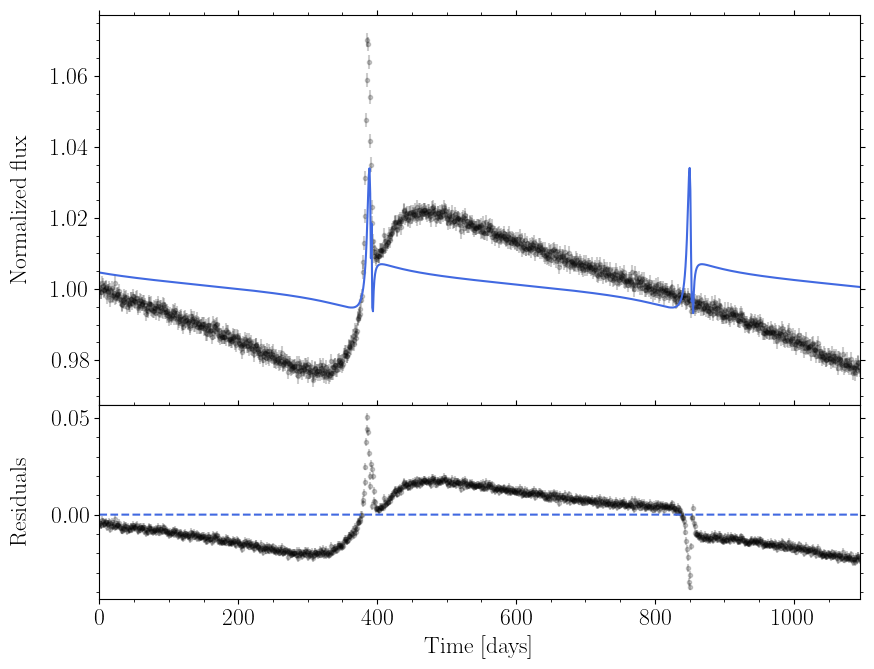

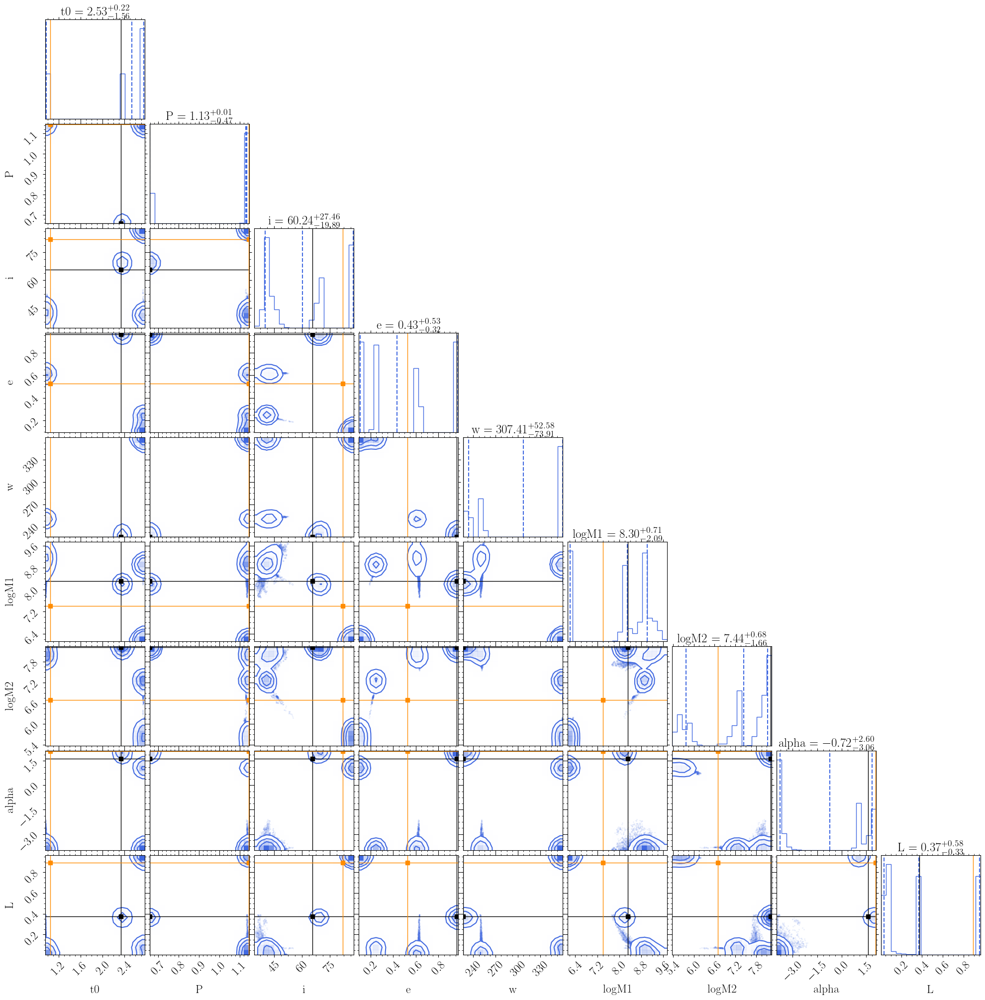

In [128]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

---
### 1.2. Model with UltraNest
```
logZ = -120239.291 +- 0.588
  single instance: logZ = -120239.291 +- 0.350
  bootstrapped   : logZ = -120239.382 +- 0.588
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 0.92 (should be >1), far enough fraction: 45.70% : very fishy. 
Double nsteps and see if fraction and lnZ change)
    t0                  : 1.05509│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │1.05767    1.05640 +- 0.00030
    P                   : 1.14529│ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▆▇▇▇▆▆▄▄▃▃▂▂▁▁▁▁▁▁▁▁ │1.15323    1.14949 +- 0.00096
    i                   : 82.150│ ▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▆▇▇▇▆▆▅▄▃▂▂▂▁▁▁▁▁ ▁▁▁ │82.727    82.438 +- 0.067
    e                   : 0.5147│ ▁  ▁▁▁▁▁▁▁▁▂▂▄▅▆▆▇▇▇▇▇▆▅▄▃▂▁▁▁▁▁▁▁▁▁▁ │0.5276    0.5214 +- 0.0014
    w                   : 87.76 │ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▅▆▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │89.29     88.54 +- 0.18
    logM1               : 7.208 │ ▁  ▁▁▁▁▁▁▂▂▃▃▅▅▆▇▇▇▇▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁ │7.297     7.252 +- 0.010
    logM2               : 5.62  │ ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▇▇▇▆▅▄▂▁▁▁▁▁ │6.58      6.27 +- 0.10
    L                   : 0.9803│ ▁       ▁ ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▇│1.0000    0.9981 +- 0.0018
    alpha               : 2.121 │ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁ ▁ │2.209     2.162 +- 0.011
    
Execution time: 5:48:56.253900 [h:mm:ss]120185.70 [-120186.5422..-120186.5419]*| it/evals=23036/18887751 eff=0.1220% N=400 

```

In [78]:
filename = rdir / 'spikey_whitenoise_ultranest_24h3yr'

In [79]:
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.9, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.1]
priors.i     = [0, 90]
priors.e     = [0, 0.9]
priors.w     = [0, 180] # Wrapping is used
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [-4, 4]
priors.vz    = params.vz

In [90]:
%%time
result, sampler = bs.run_ultranest(
    df, params, priors, 
    odir=filename
)

In [ ]:
# result = ut.load_result(rdir/filename/'result.npy')

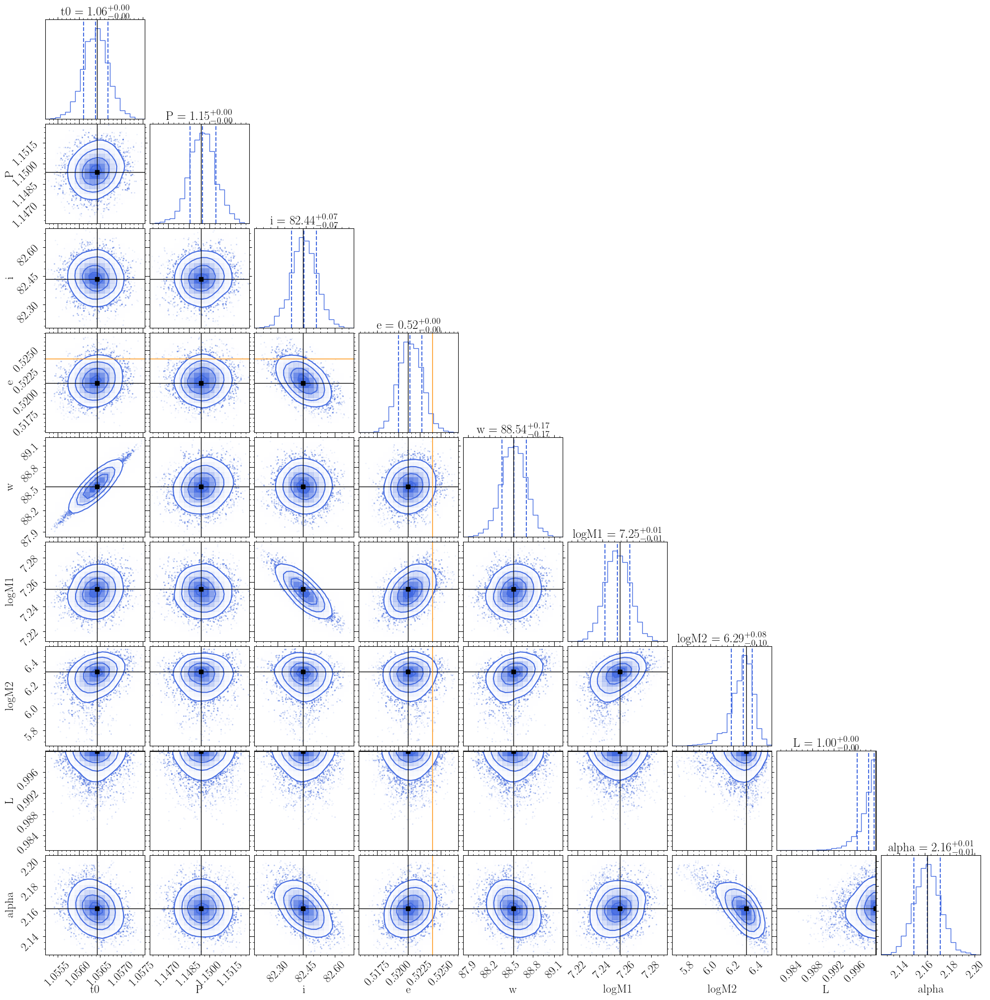

In [91]:
# Show corner plot
names = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
true_params = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]
best_params = result['maximum_likelihood']['point']
fig = pt.plot_corner(result, names=names, true_params=true_params, best_params=best_params);

---
### 1.3. Model with JAXNS
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 76421223
samples: 88176
phantom samples: 0
likelihood evals / sample: 866.7
phantom fraction (%): 0.0%
--------
logZ=5627.14 +- 0.17
max(logL)=5673.04
H=-41.76
ESS=4952
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.43 +- 0.28 | 0.03 / 0.55 / 0.74 | 0.07 | 0.07
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.1433 +- 0.0027 | 1.1398 / 1.1433 / 1.1468 | 1.1437 | 1.1437
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.0 +- 0.16 | 1.8 / 2.04 / 2.2 | 2.1 | 2.1
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.5217 +- 0.0038 | 0.517 / 0.5217 / 0.5267 | 0.5219 | 0.5219
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 82.04 +- 0.24 | 81.74 / 82.04 / 82.36 | 81.87 | 81.87
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.99 +- 0.74 | 5.87 / 7.42 / 7.57 | 6.86 | 6.86
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.3 +- 1.0 | 5.1 / 6.2 / 7.5 | 7.4 | 7.4
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.04954 +- 0.00083 | 1.04849 / 1.04954 / 1.05062 | 1.04976 | 1.04976
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 162.0 +- 89.0 | 84.0 / 85.0 / 265.0 | 265.0 | 265.0
--------
CPU times: user 11h 49min 58s, sys: 6min 38s, total: 11h 56min 37s
Wall time: 1h 54min 3s
```

In [11]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr24h.npy'

In [23]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [15]:
result = ut.load_result(filename)

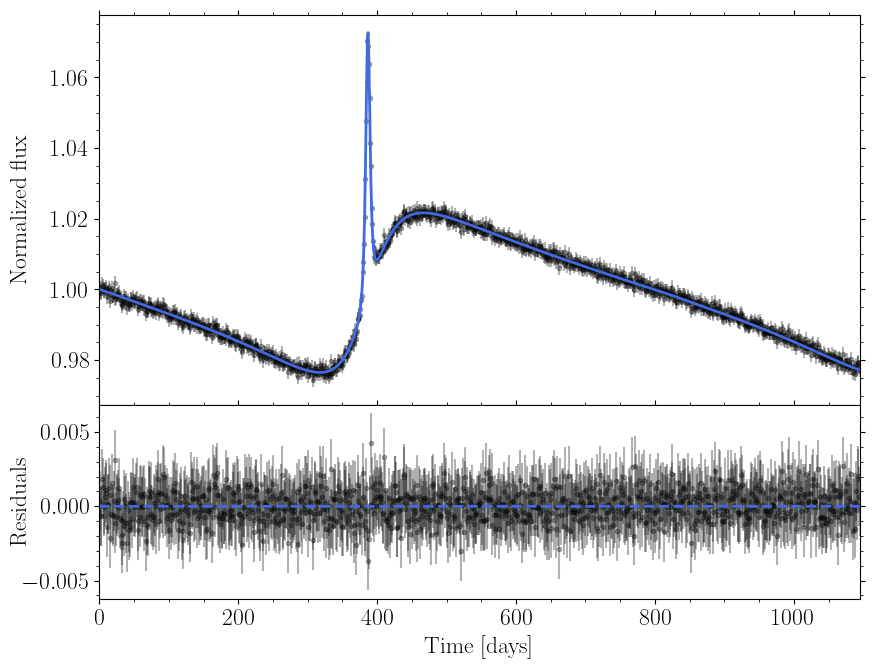

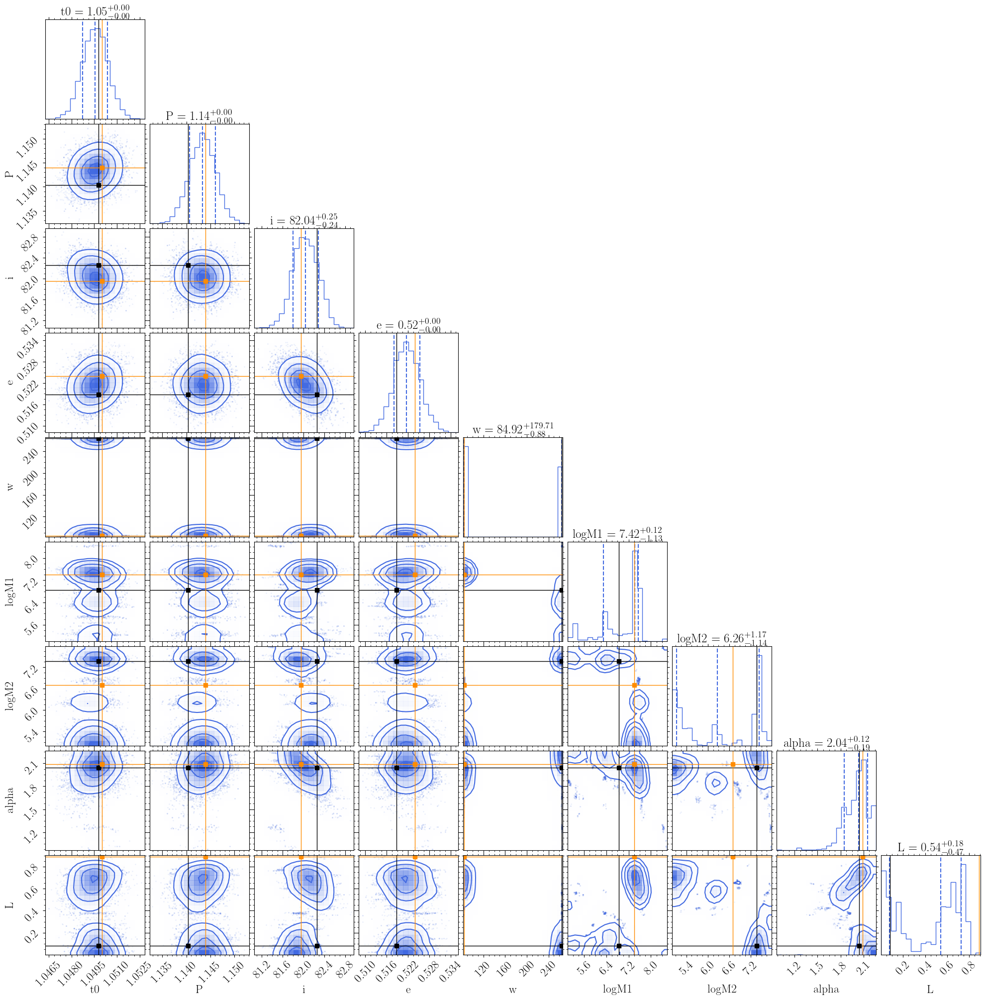

In [16]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

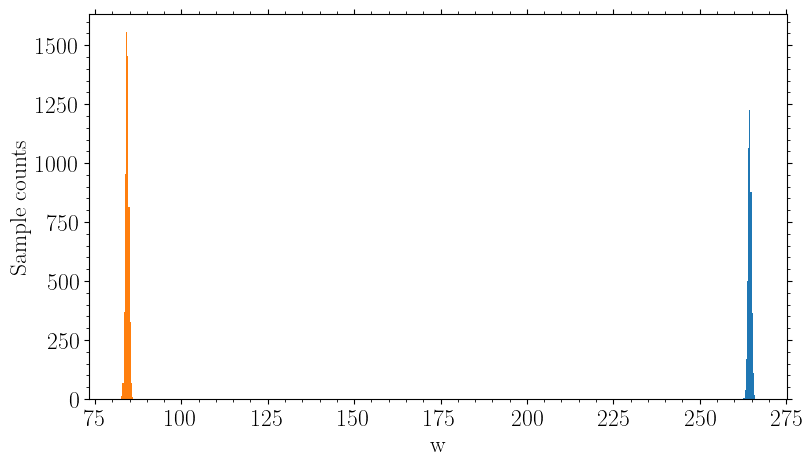

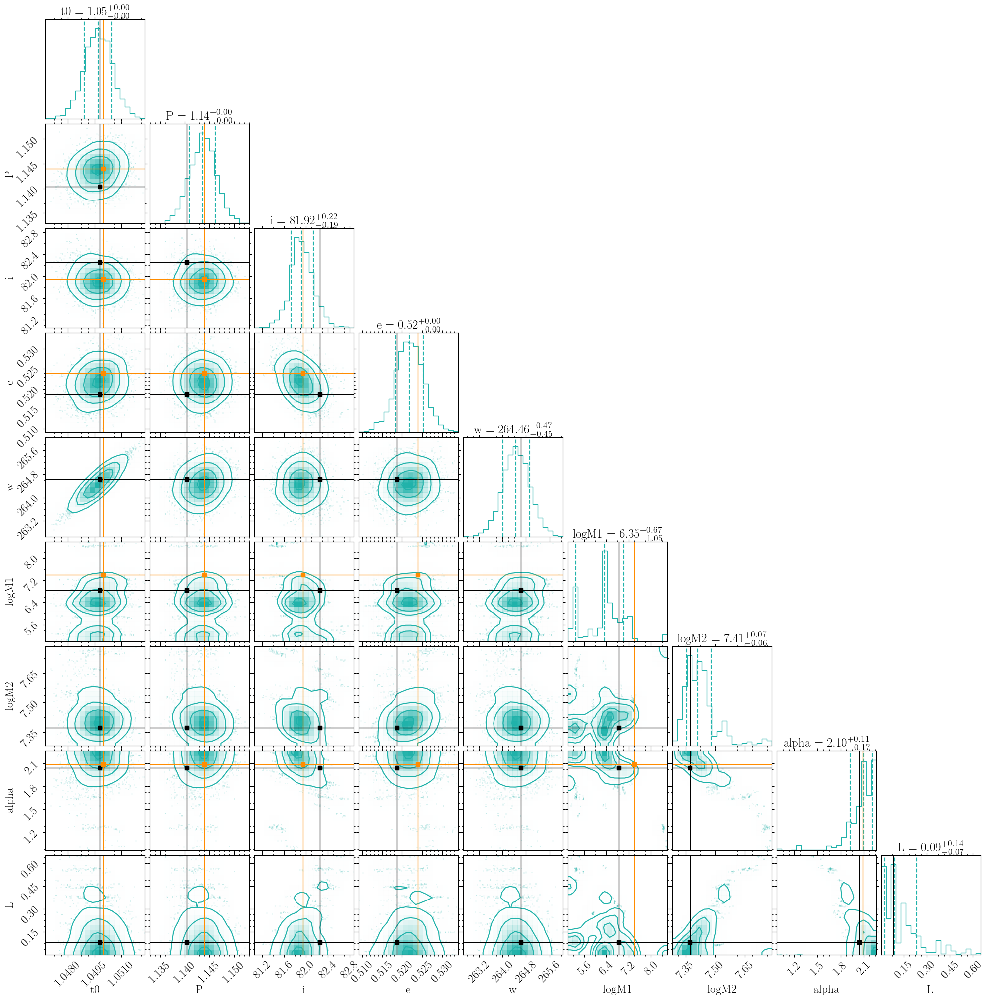

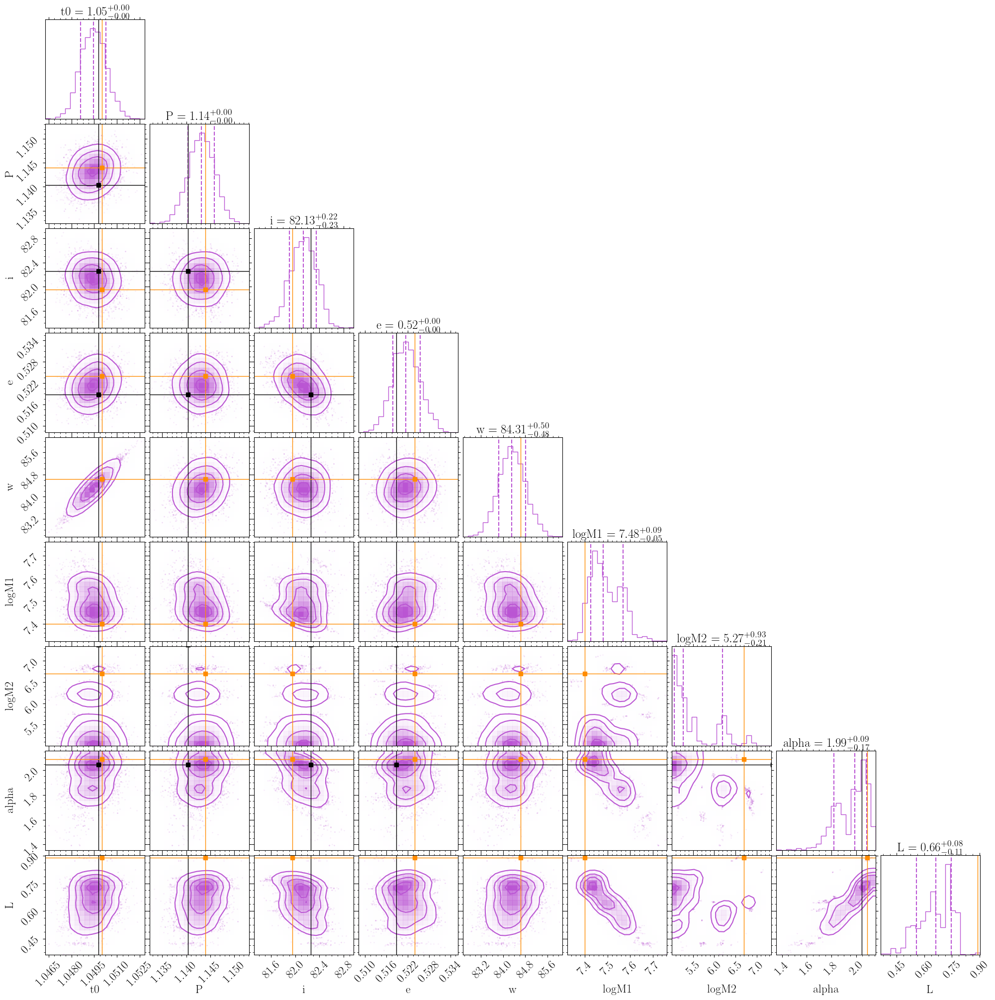

In [17]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
## 2. Test model parameterisation {logM, q}
---
TODO test JAXNS with new paramterisation. Below we proceed with JAXNS nested sampling software for further analysis.

---
### 1.1. Model with UltraNest

In [ ]:
# # Generate relativistic Spikey model with correct parameterization
# params = smbhb.model_params_q()
# params.sigma = 0 
# model = smbhb.model_q(params)
# dm = model.light_curve(time, df=True)
# params_input = [params.t0, params.P, params.i, params.e, params.w, params.logM, params.q, params.L, params.alpha]

In [23]:
# filename = 'spikey_whitenoise_24h3yr_logMq_jaxns'
# priors = bs.model_priors_q()
# priors.z     = params.z
# priors.t0    = [0.1, 3.]
# priors.P     = [0.1, 3.]
# priors.i     = [0.1, 89]
# priors.e     = [0.1, 0.9]
# priors.w     = [0.1, 359]
# priors.logM  = [5., 11.]
# priors.q     = [0., 1.]
# priors.L     = [0., 1.]
# priors.alpha = [0.1, 4.]
# priors.vz    = params.vz

In [21]:
# # Run UltraNest analysis
# result, sampler = bs.run_ultranest_q(df, params, priors, rdir/filename)
# # Show corner plot
# fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
# fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200)
# # Create best-fit model and plot along with data
# params_model = copy.deepcopy(params)
# params_model.sigma = 0
# dm = bs.bestfit_model_q(time, params_model, result)
# fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6));
# fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

---
### 2.2. Model with JAXNS

In [22]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr24h_logMq.npy'

In [23]:
%%time
result = bs.run_jaxns(
    df, params_logMq, priors_logMq, 
    bs.smbhb_mean_builder, 
    ofile=filename
)

In [ ]:
# result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

---
## 3. Test light curve duration
---

In this section we test the light curve duration which shows:

- Increasing the light curve duration, increases the model accuracy (expected)
- For a 2-yr light curve the `w ~ 84 deg` solution dominates the posterior, while for a 4-yr light curves the `w ~ 264 deg` dominates the posterior. This is a quite unexpected result as you would expect to get closer to the injected value of `w` with a longer duration. However, the 
- What does significantly improve with two self-lensing events are the precision on the timings `t0` and `P`.

---
### 3.1. Use 2-yr duration
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 77917220
samples: 86172
phantom samples: 0
likelihood evals / sample: 904.2
phantom fraction (%): 0.0%
--------
logZ=3738.13 +- 0.17
max(logL)=3782.23
H=-40.21
ESS=4808
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.76 +- 0.25 | 0.34 / 0.86 / 0.96 | 0.97 | 0.97
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.144 +- 0.011 | 1.131 / 1.144 / 1.159 | 1.141 | 1.141
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.02 +- 0.14 | 1.81 / 2.05 / 2.15 | 2.22 | 2.22
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.5226 +- 0.0066 | 0.5142 / 0.5225 / 0.5311 | 0.521 | 0.521
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 81.93 +- 0.27 | 81.58 / 81.93 / 82.27 | 81.83 | 81.83
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 7.34 +- 0.33 | 6.81 / 7.43 / 7.53 | 7.36 | 7.36
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.71 +- 0.61 | 6.11 / 6.88 / 7.49 | 6.12 | 6.12
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.04991 +- 0.0009 | 1.04875 / 1.04992 / 1.05104 | 1.05007 | 1.05007
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 112.0 +- 64.0 | 84.0 / 85.0 / 264.0 | 85.0 | 85.0
--------
CPU times: user 8h 40min 29s, sys: 4min 47s, total: 8h 45min 17s
Wall time: 1h 23min 48s
```

In [18]:
filename = rdir / 'spikey_whitenoise_jaxns_2yr24h.npy'
df, params = generate_noise_model(cadence=1, tdur=2, plot_lc=False)

In [ ]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [19]:
result = ut.load_result(filename)

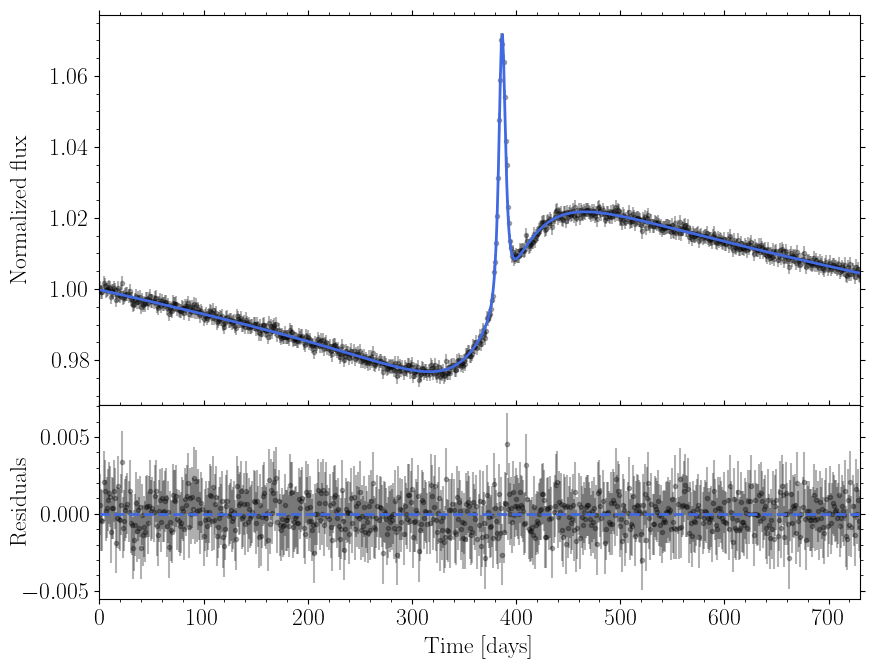

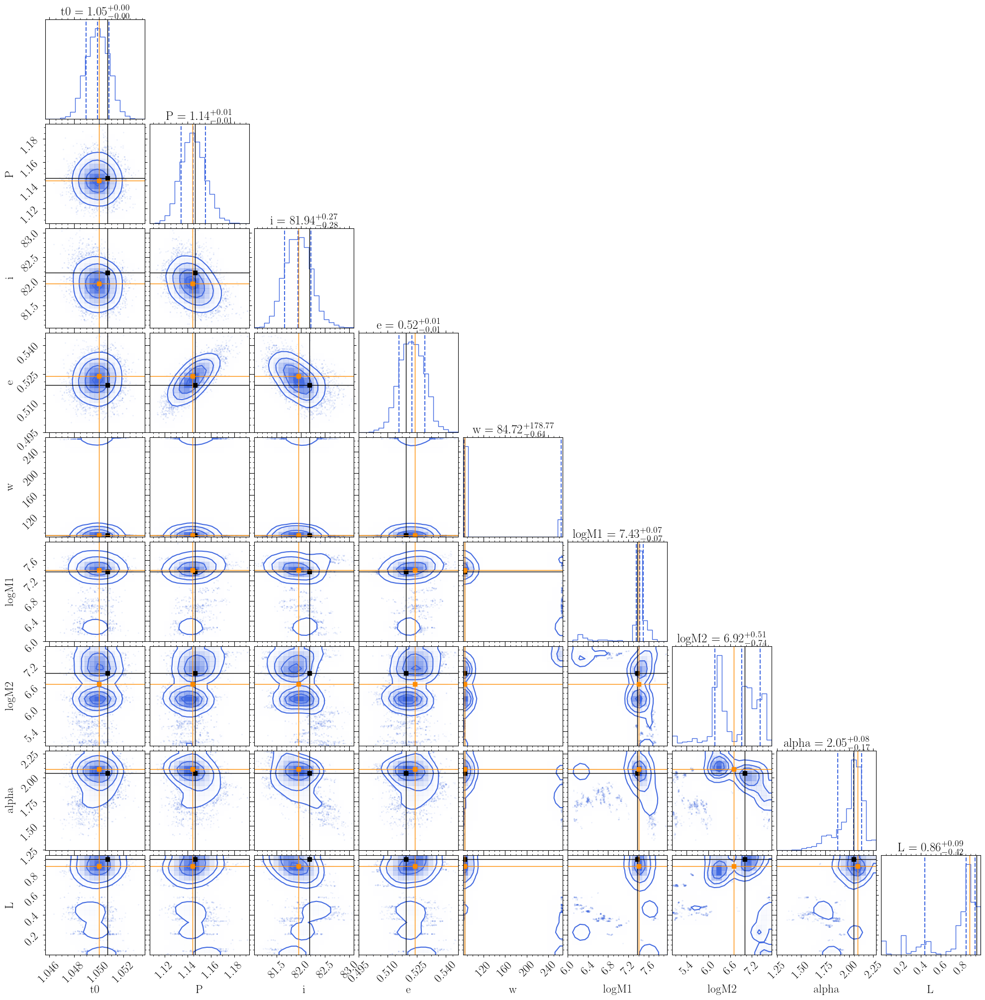

In [20]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

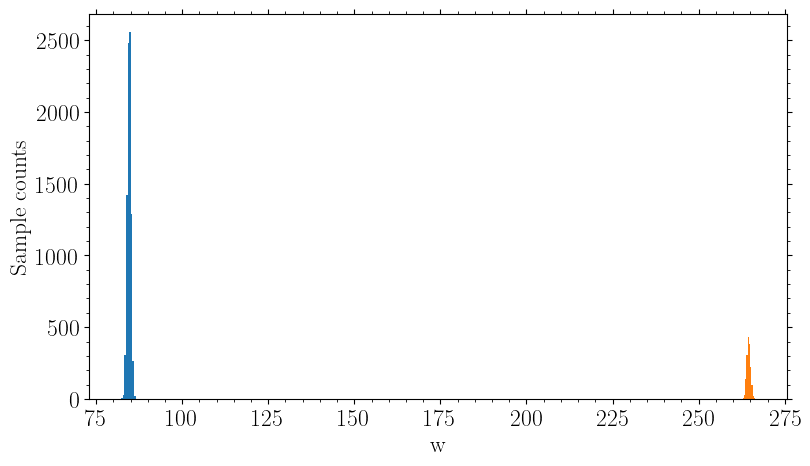

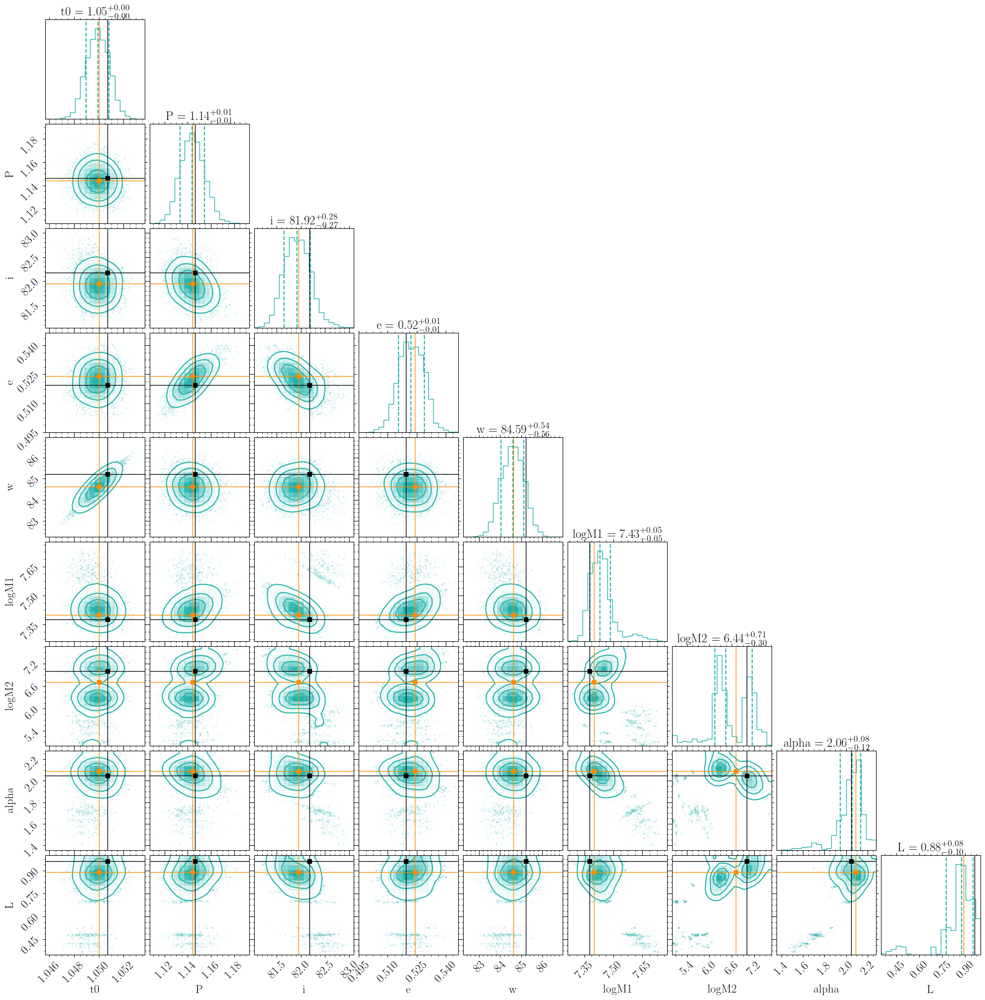

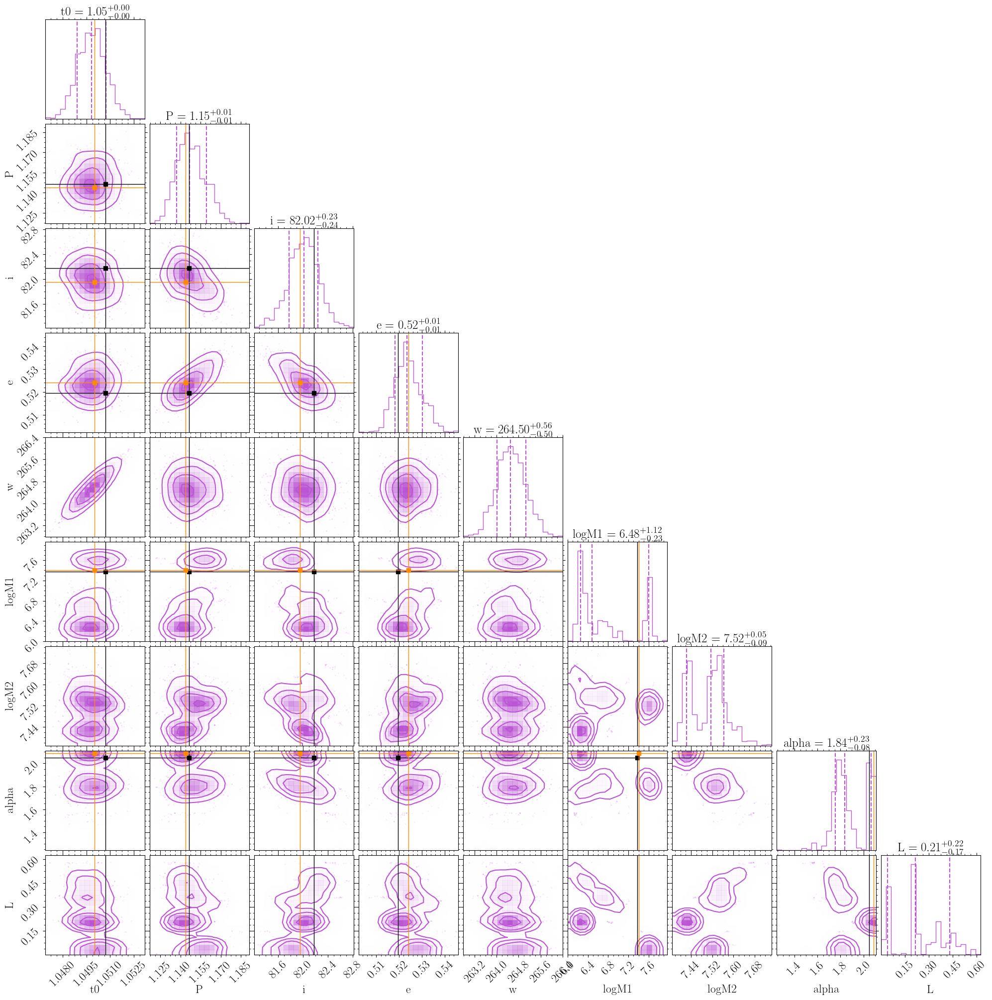

In [21]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
### 3.2. Use 4-yr duration
```
INFO:jaxns:Number of Markov-chains set to: 2000

Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 95147229
samples: 95190
phantom samples: 0
likelihood evals / sample: 999.6
phantom fraction (%): 0.0%
--------
logZ=7510.31 +- 0.18
max(logL)=7560.81
H=-47.02
ESS=4514
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.2 +- 0.19 | 0.09 / 0.15 / 0.4 | 0.76 | 0.76
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.14401 +- 0.00011 | 1.14386 / 1.14401 / 1.14415 | 1.144 | 1.144
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.163 +- 0.042 | 2.114 / 2.167 / 2.208 | 2.095 | 2.095
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.5241 +- 0.0027 | 0.5204 / 0.5244 / 0.5274 | 0.5235 | 0.5235
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 81.88 +- 0.15 | 81.68 / 81.89 / 82.06 | 81.99 | 81.99
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 5.63 +- 0.63 | 5.26 / 5.4 / 5.98 | 7.43 | 7.43
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 7.17 +- 0.67 | 7.33 / 7.39 / 7.41 | 5.13 | 5.13
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.04983 +- 0.00065 | 1.049 / 1.04982 / 1.05068 | 1.0497 | 1.0497
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 247.0 +- 53.0 | 264.0 / 264.0 / 265.0 | 84.0 | 84.0
--------
CPU times: user 19h 28min 43s, sys: 8min 7s, total: 19h 36min 51s
Wall time: 3h 6min 32s
```

In [23]:
filename = rdir / 'spikey_whitenoise_jaxns_4yr24h.npy'
df, params = generate_noise_model(cadence=1, tdur=4, plot_lc=False)

In [24]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [25]:
result = ut.load_result(filename)

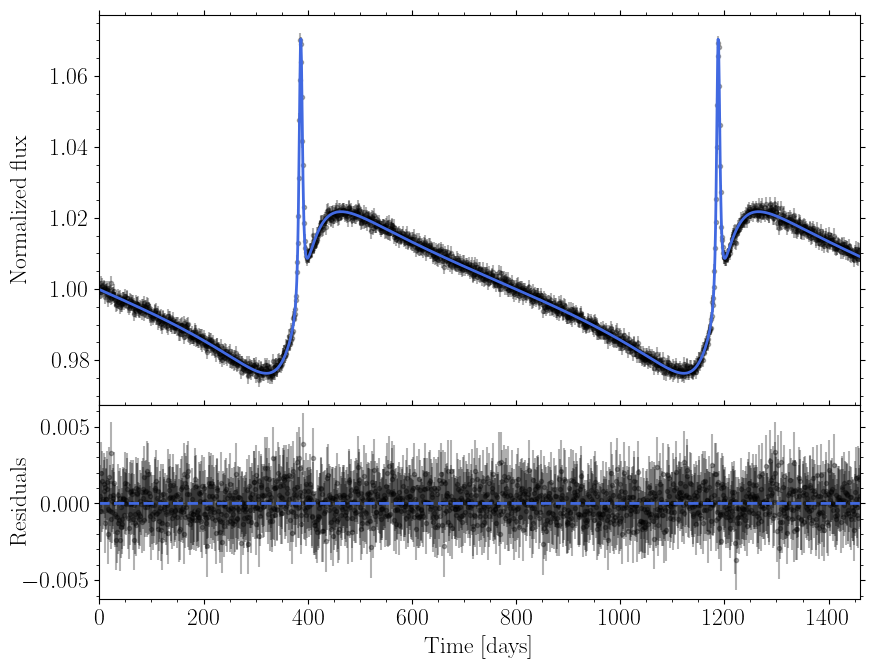

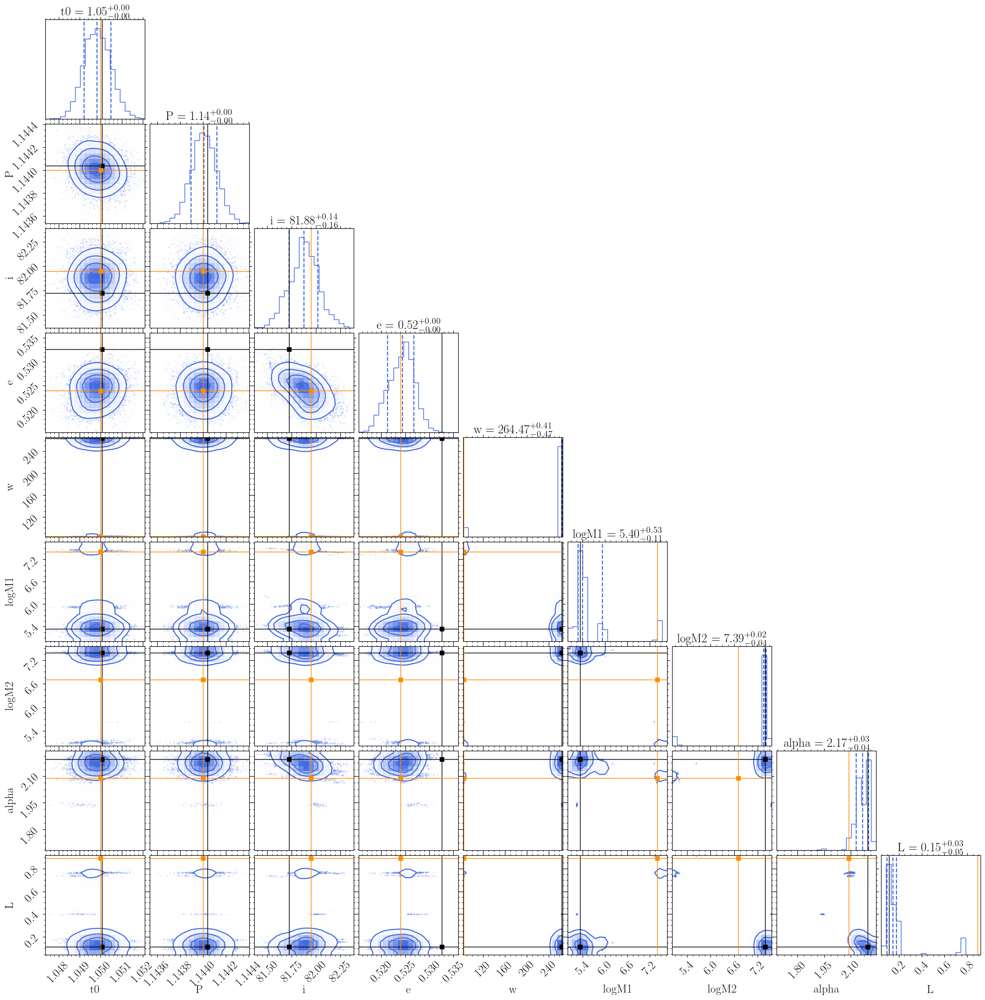

In [26]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

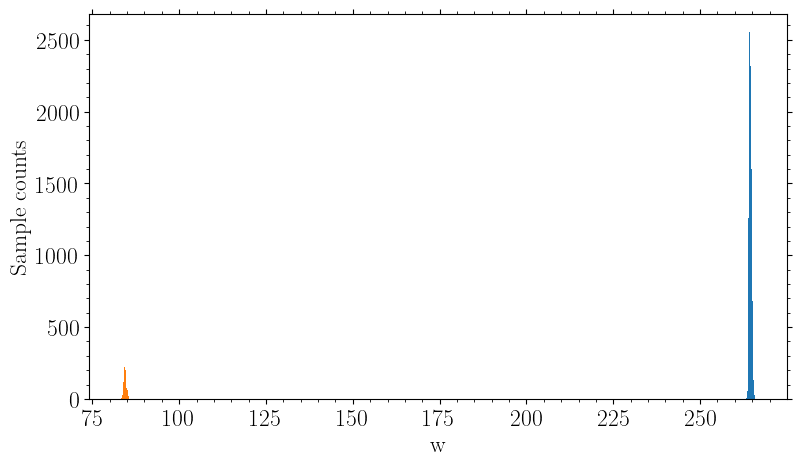

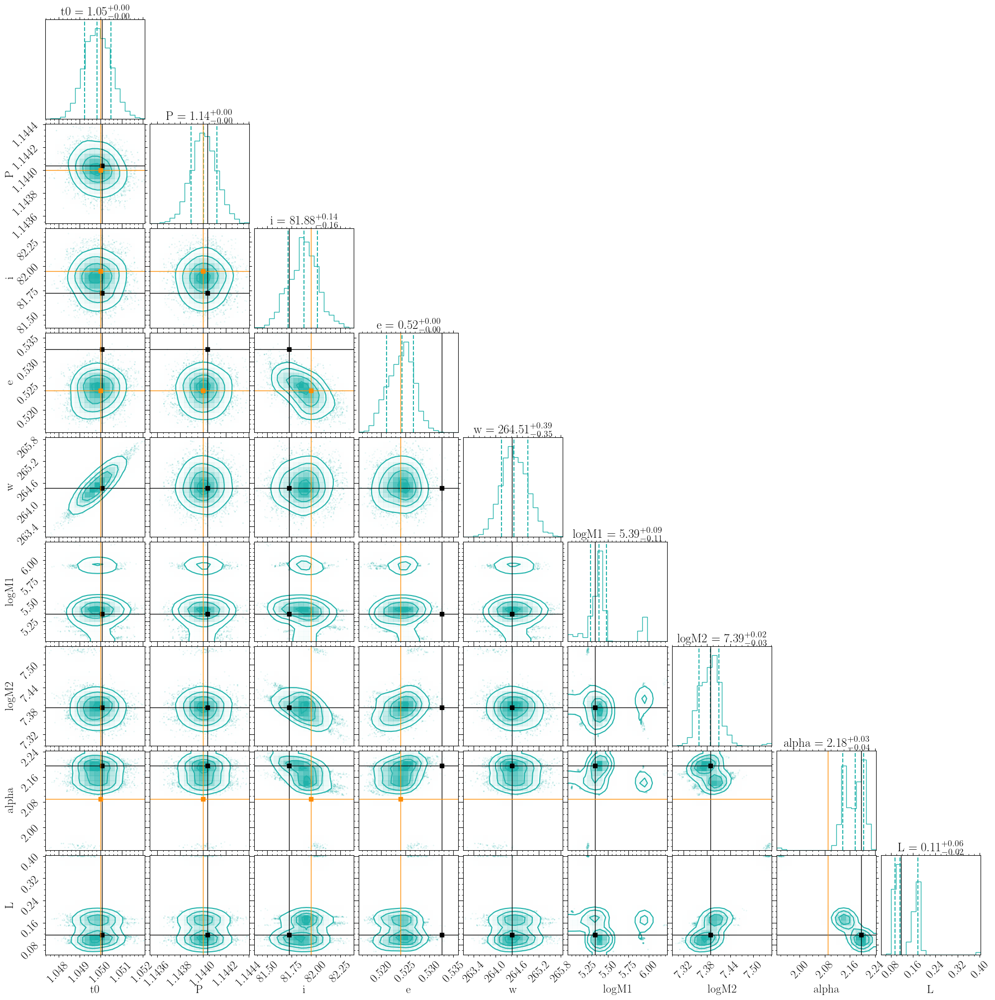

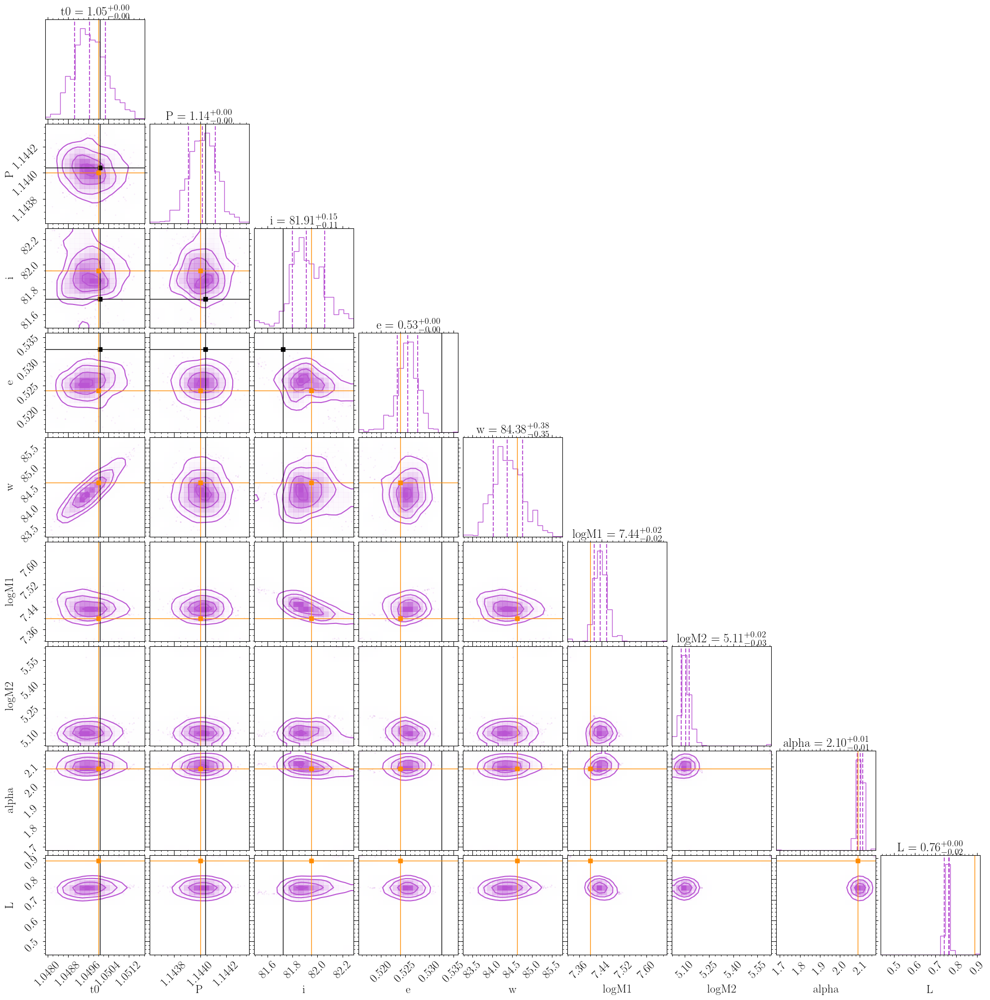

In [27]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
## 4. Test light curve cadence
---

This section shows that:
- The lower the cadence, the better the modelling performs (as expected).
- The higher the cadence, the lower the model residuals are around the SLF (as expected).
- However, again, it's clear that there is an inherent generacy among the parameters `logM1`, `logM2`, `alpha`, and `L`.
- We have so far seen that particularly `L` is underestimated for the pseudo unique soluition of `w ~ 84 deg`. But it is interesting that for a 6-h cadence, the solution of `w ~ 265 deg` shows further strong bimodality for the four aforementioned parameters.

---
### 4.1. Use 72-h cadence
```
INFO:jaxns:Number of Markov-chains set to: 2000

Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 68413526
samples: 81162
phantom samples: 0
likelihood evals / sample: 842.9
phantom fraction (%): 0.0%
--------
logZ=1852.83 +- 0.16
max(logL)=1893.74
H=-37.19
ESS=4782
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.59 +- 0.25 | 0.26 / 0.58 / 0.95 | 0.86 | 0.86
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.1432 +- 0.0046 | 1.1372 / 1.1432 / 1.1493 | 1.1437 | 1.1437
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 1.89 +- 0.26 | 1.51 / 1.96 / 2.18 | 2.05 | 2.05
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.5285 +- 0.0068 | 0.5199 / 0.5282 / 0.5371 | 0.5288 | 0.5288
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 82.17 +- 0.43 | 81.63 / 82.16 / 82.74 | 81.97 | 81.97
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.98 +- 0.72 | 5.77 / 7.38 / 7.61 | 7.41 | 7.41
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 6.54 +- 0.88 | 5.21 / 6.55 / 7.56 | 6.7 | 6.7
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.0505 +- 0.0014 | 1.0488 / 1.0505 / 1.0523 | 1.0508 | 1.0508
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 149.0 +- 86.0 | 84.0 / 86.0 / 265.0 | 85.0 | 85.0
--------
CPU times: user 3h 8min 22s, sys: 3.28 s, total: 3h 8min 25s
Wall time: 34min 56s
```

In [41]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr72h.npy'
df, params = generate_noise_model(cadence=72/24, tdur=3, plot_lc=False)

In [ ]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [ ]:
result = ut.load_result(filename)

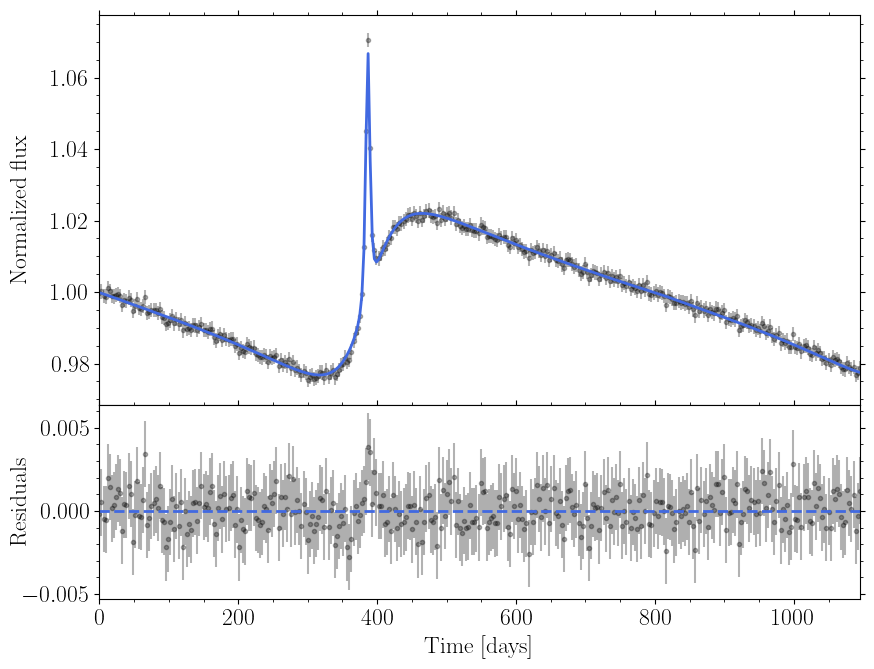

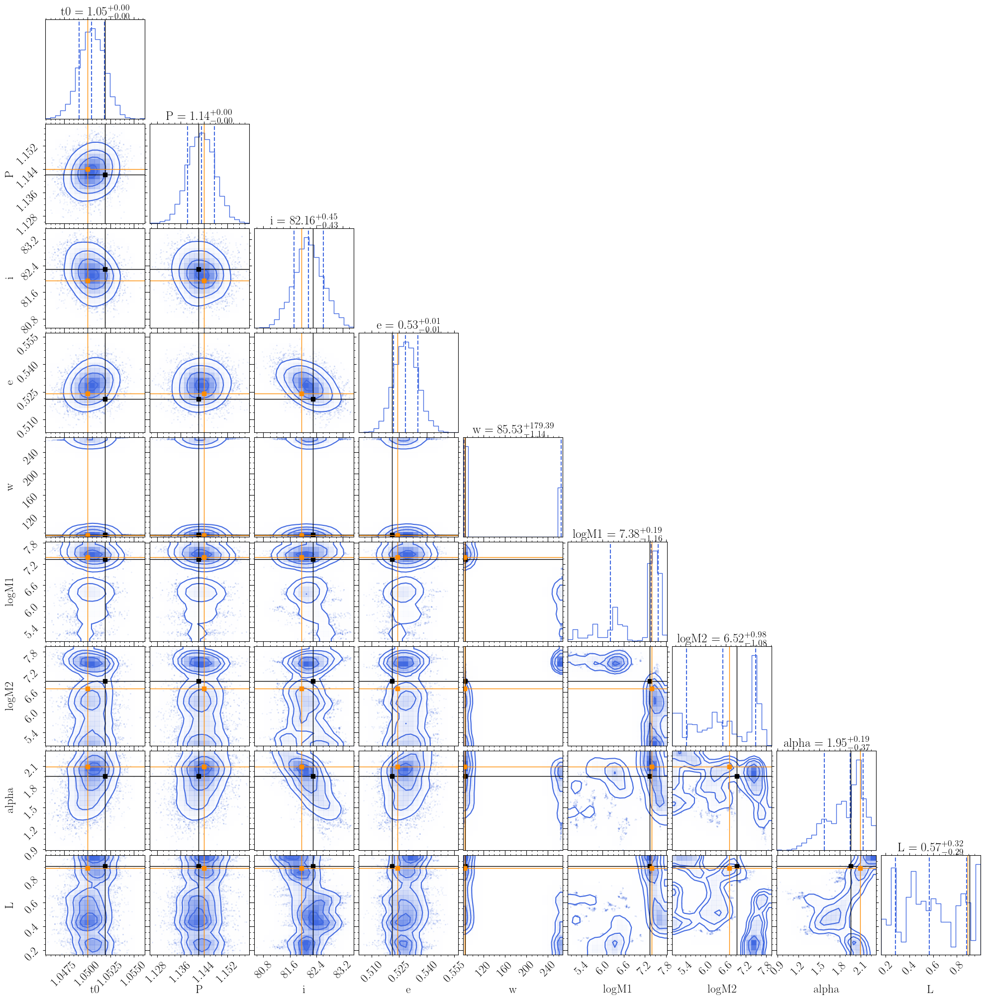

In [43]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

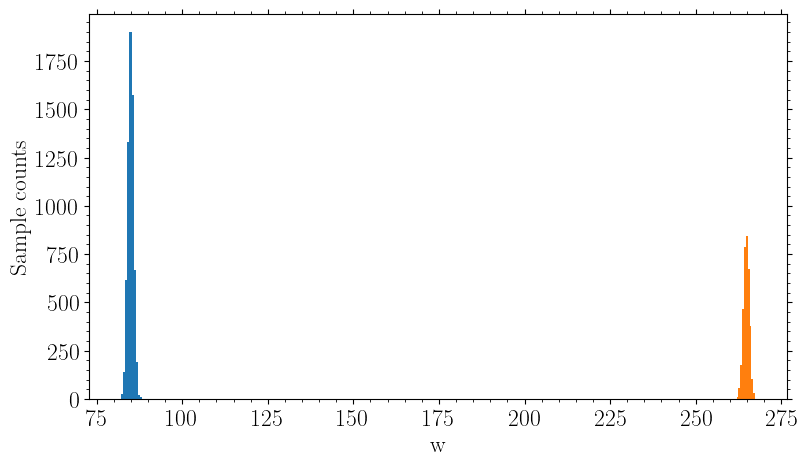

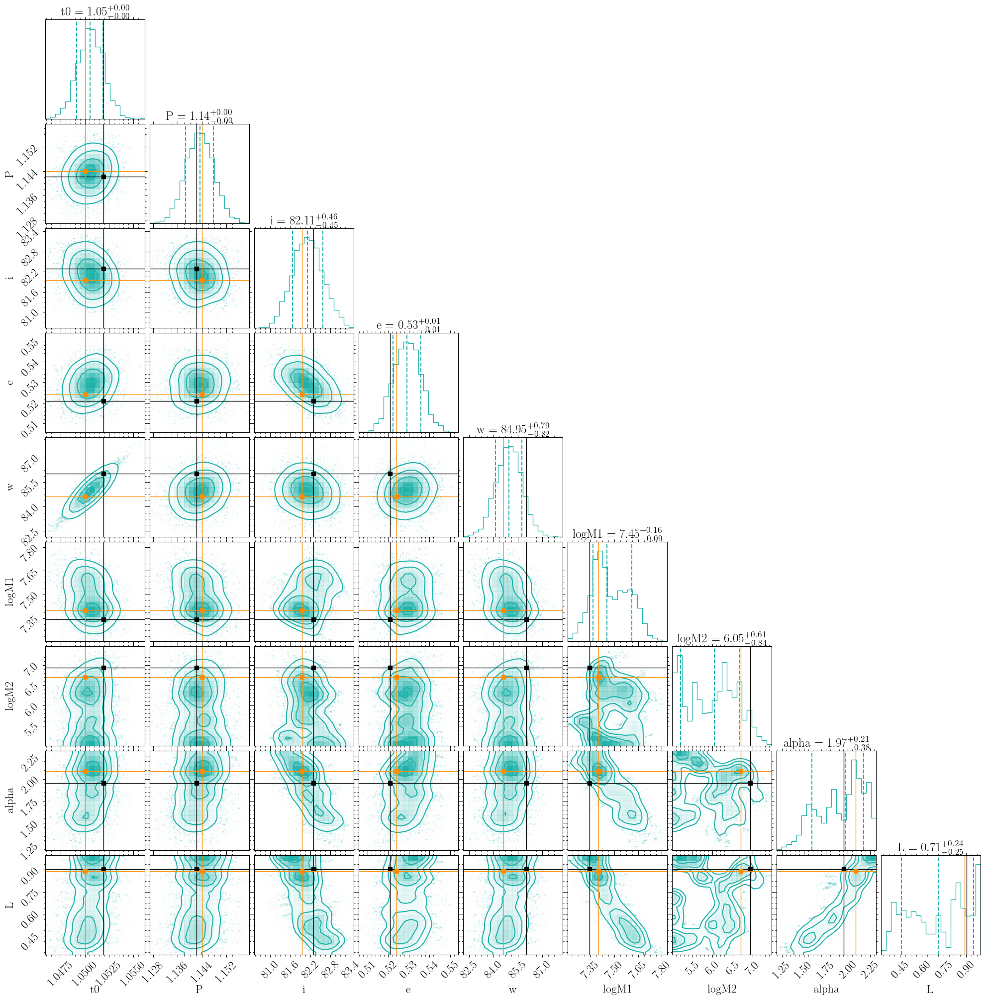

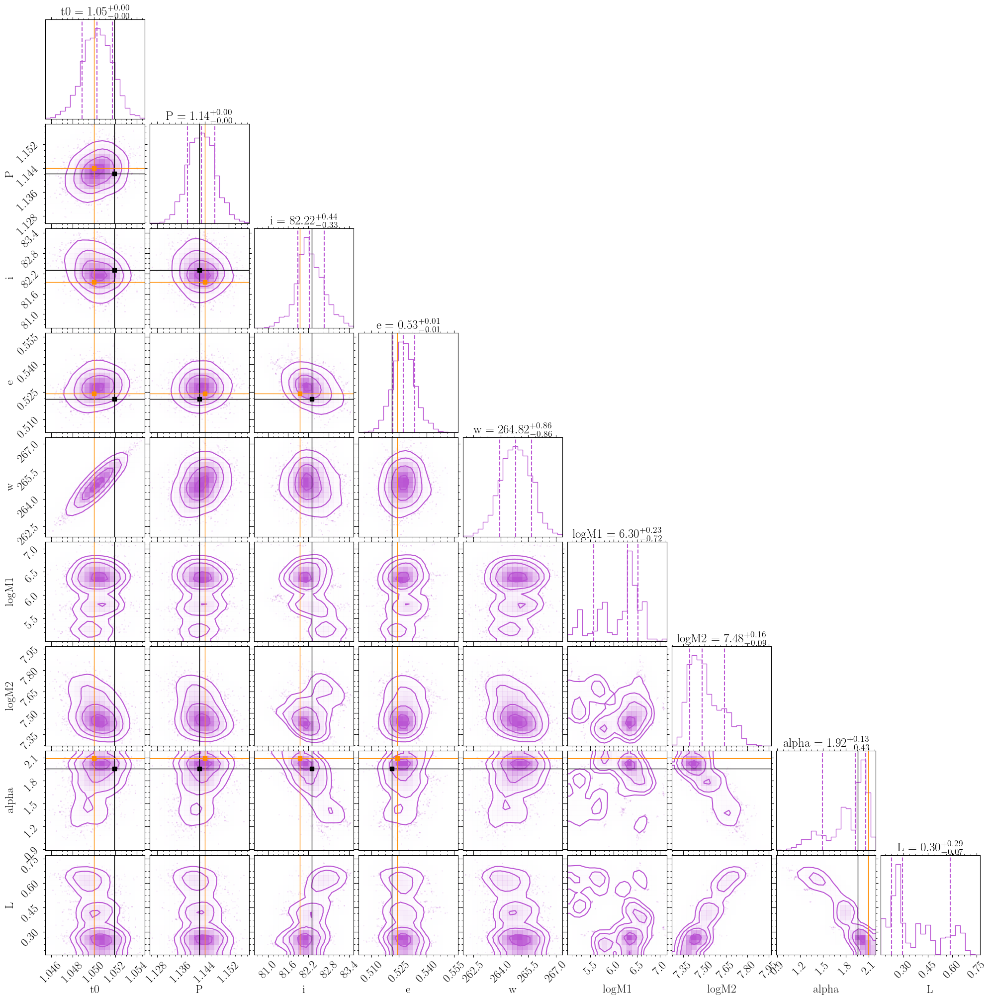

In [44]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
### 4.2. Use 12-h cadence
```
INFO:jaxns:Number of Markov-chains set to: 2000
Running over 6 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 84143812
samples: 92184
phantom samples: 0
likelihood evals / sample: 912.8
phantom fraction (%): 0.0%
--------
logZ=11288.15 +- 0.18
max(logL)=11336.5
H=-44.13
ESS=4843
--------
L: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
L: 0.39 +- 0.31 | 0.06 / 0.31 / 0.92 | 0.97 | 0.97
--------
P: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
P: 1.1437 +- 0.0019 | 1.1412 / 1.1436 / 1.1462 | 1.144 | 1.144
--------
alpha: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
alpha: 2.07 +- 0.11 | 1.94 / 2.08 / 2.2 | 2.12 | 2.12
--------
e: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
e: 0.5242 +- 0.0027 | 0.5208 / 0.5242 / 0.5277 | 0.5243 | 0.5243
--------
i: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
i: 82.04 +- 0.18 | 81.81 / 82.02 / 82.28 | 81.92 | 81.92
--------
logM1: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM1: 6.39 +- 0.86 | 5.2 / 6.11 / 7.46 | 7.39 | 7.39
--------
logM2: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
logM2: 7.09 +- 0.53 | 6.06 / 7.38 / 7.48 | 6.87 | 6.87
--------
t0: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
t0: 1.04981 +- 0.00058 | 1.04907 / 1.04981 / 1.05054 | 1.04992 | 1.04992
--------
w: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
w: 206.0 +- 84.0 | 84.0 / 264.0 / 265.0 | 85.0 | 85.0
--------
CPU times: user 1d 1h 24min 11s, sys: 8min 38s, total: 1d 1h 32min 50s
Wall time: 4h 1min 45s
```

In [45]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr12h.npy'
df, params = generate_noise_model(cadence=12/24, tdur=3, plot_lc=False)

In [ ]:
# %%time
# result = bs.run_jaxns(
#     df, params, priors, 
#     bs.smbhb_mean_builder, 
#     ofile=filename
# )

In [ ]:
result = ut.load_result(filename)

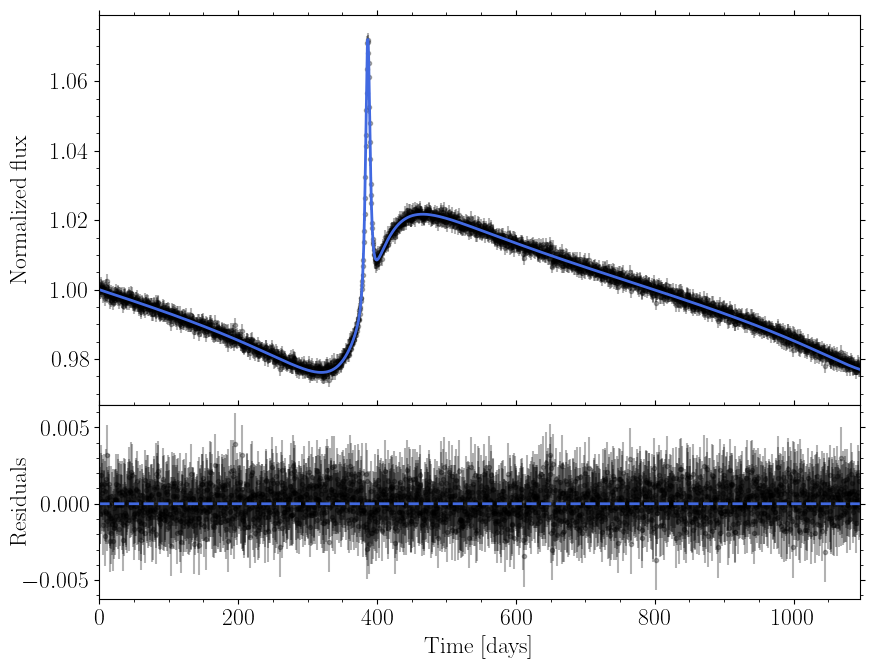

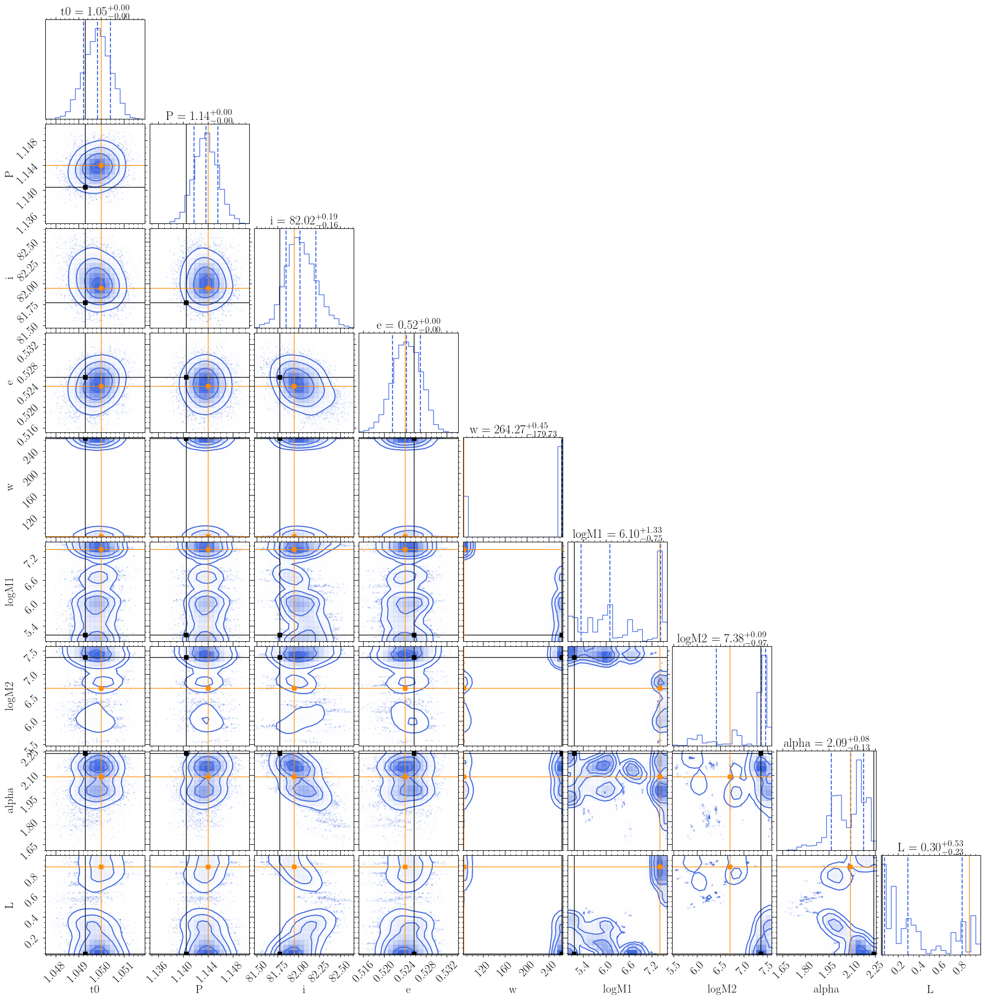

In [47]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

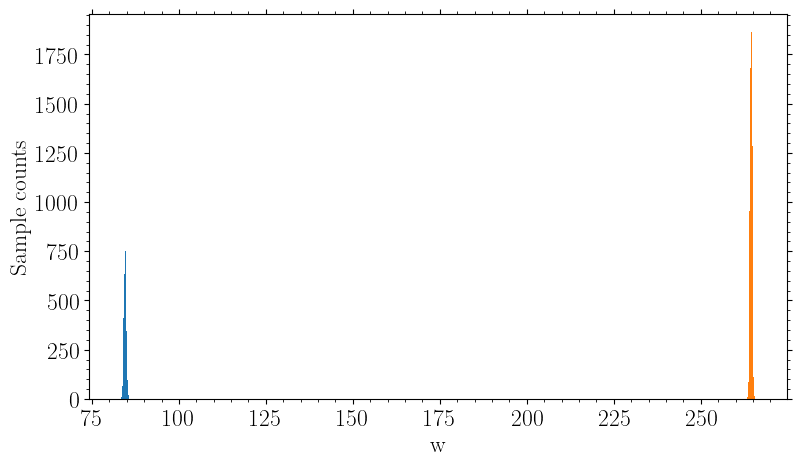

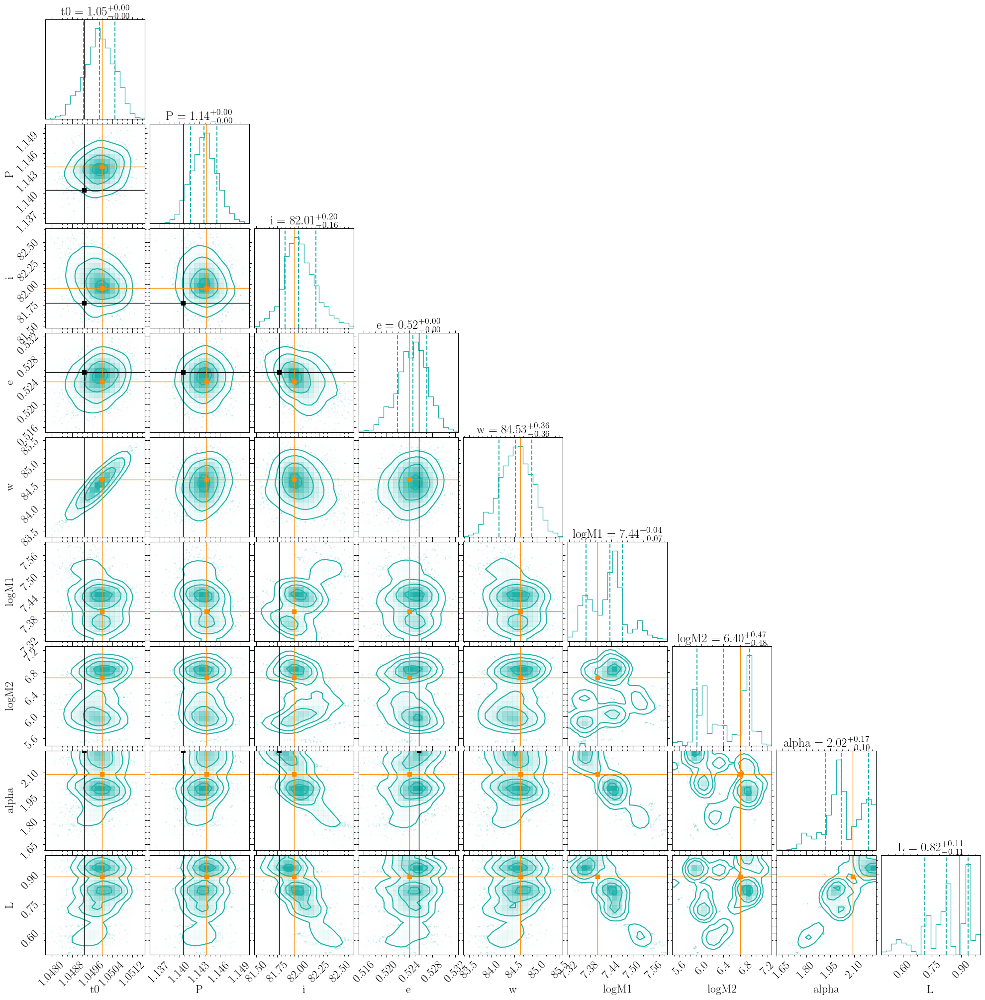

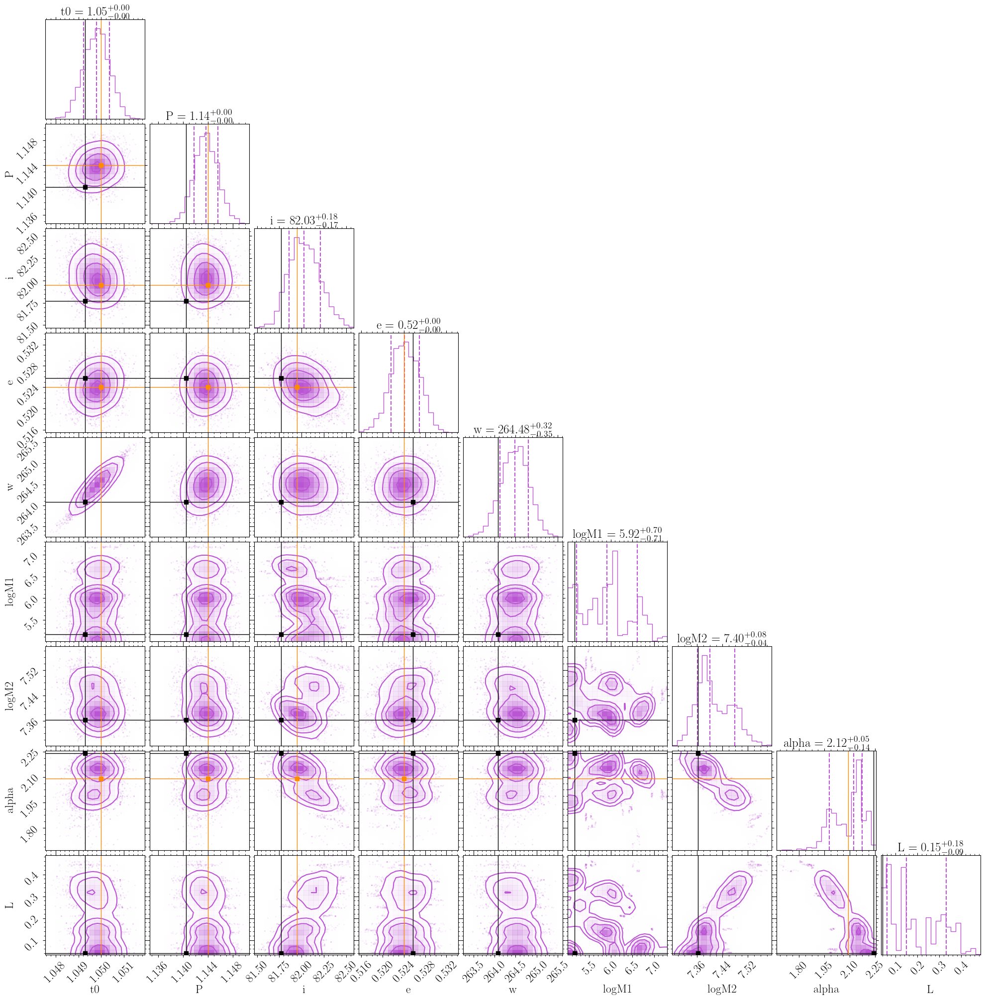

In [48]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
### 4.3. Use 6-h cadence

In [49]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr06h.npy'
df, params = generate_noise_model(cadence=6/24, tdur=3, plot_lc=False)

In [29]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
## 5. Test ligh curve quality
---

It's clear that a better the data quality (the lower noise level), the better the modelling. This narrows down the biodality in `w`. After selecting best model posterior of `w`, we also see that the bimodality in the remaining model parameters decreases, however, it doesn't disappear fully.

---
### 5.1. Use 10 ppt noise level

In [ ]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr24h100ppm.npy'
df, params = generate_noise_model(cadence=1, tdur=3, noise_level=1e-4, plot_lc=False)

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c2)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c3)

---
### 5.1. Use 0.1 ppt noise level

In [ ]:
filename = rdir / 'spikey_whitenoise_jaxns_3yr24h100ppm.npy'
df, params = generate_noise_model(cadence=1, tdur=3, noise_level=1e-4, plot_lc=False)

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c2)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c3)

---
## 6. Test other cases
---

This section shows 

- (not supringly) that the binning used in Hu+2020 has a negative result on the fitting of the Doppler boosting. While the estimation of `e` has been pinned down more precisely, the otherall model becomes more generate.

---
### 6.1. Use Hu+2020 sampling (12-h around spike, 9-d elsewhere)

In [ ]:
# Create a 12-h cadence light curve
df_bin_12h, params = generate_noise_model(cadence=12/24, tdur=3, plot_lc=False)

# Bin the DM to 9-d cadence light curve
df_bin_9d = ut.bin_lc(df_bin_12h, bin_size=9)

# Replace spike with 0.5-d cadence data
tmin, tmax = 374, 400
df0 = df_bin_9d[df_bin_9d.time < tmin]
df1 = df_bin_12h[(df_bin_12h.time > tmin) & (df_bin_12h.time < tmax)]
df2 = df_bin_9d[df_bin_9d.time > tmax]
df = pd.concat([df0, df1, df2])

# Plot final light curve
pt.plot_lc(df);

In [ ]:
filename = rdir / 'spikey_whitenoise_jaxns_hu2020.npy'

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)

In [ ]:
result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm)
fig = pt.plot_corner(result, best_params='mle', true_params=True);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c0)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c1)

---
### 6.2. Use 1-d cadence, 4-yr duration, and 100-ppm noise level

In [ ]:
filename = rdir / 'spikey_whitenoise_jaxns_4yr24h100ppm.npy'
df, params = generate_noise_model(cadence=1, tdur=3, noise_level=1e-4, plot_lc=True)

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)
# result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c1, alpha=0.3)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c1);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c2)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c3)

---
## 7. Test other Spikey-like light curves
---

Conclusion..

---
### 7.1. Use 

In [ ]:
filename = rdir / 'spikey_whitenoise_jaxns_4yr24h100ppm.npy'
df, params = generate_noise_model(cadence=1, tdur=3, noise_level=1e-4, plot_lc=True)

In [ ]:
%%time
result = bs.run_jaxns(
    df, params, priors, 
    bs.smbhb_mean_builder, 
    ofile=filename
)
# result = ut.load_result(filename)

In [ ]:
# Show results
dm = smbhb.model_lightcurve(df.time.to_numpy(), result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c1, alpha=0.3)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c1);

In [ ]:
# Inspect bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)
result_w0 = clusters_w[0] 
result_w1 = clusters_w[1] 
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c2)
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c3)